# Attention U-Net for Retinal Artery-Vein Segmentation
## Research-Oriented Pipeline with Curriculum Learning and Vessel-Aware Training

---

# Objective

This notebook implements a research-oriented semantic segmentation framework for retinal artery-vein (AV) segmentation using an enhanced **Attention U-Net** architecture. The pipeline is designed specifically for the GAVE-2 Challenge, focusing on accurate segmentation of **arteries, veins, overlap regions, and background** while addressing the major challenges of retinal vessel analysis, including severe class imbalance, thin vessel preservation, and vascular topology continuity.

Unlike conventional segmentation pipelines, this implementation combines intelligent preprocessing, vessel-aware patch selection, curriculum learning, topology-preserving optimization, and extensive data augmentation to improve both pixel-level accuracy and anatomical consistency.

---

# Pipeline Overview

```
Dataset Preparation
        │
        ▼
Image & Mask Analysis
        │
        ▼
CLAHE-based Image Enhancement
        │
        ▼
Ground Truth Engineering
(RGB → Multi-class Masks)
        │
        ▼
Vessel-aware High Resolution Patch Extraction
        │
        ▼
Heavy Offline Data Augmentation
        │
        ▼
PyTorch Dataset & DataLoader
        │
        ▼
Attention U-Net
(Deep Supervision)
        │
        ▼
Curriculum Learning Strategy
        │
        ▼
Hybrid Loss Optimization
(Focal Tversky + CLDice)
        │
        ▼
Training & Validation
        │
        ▼
Evaluation & Visualization
```

---

# Key Features

## Intelligent Image Preprocessing

The retinal fundus images undergo preprocessing to enhance vessel visibility before training.

Features include:

- Green channel enhancement
- CLAHE (Contrast Limited Adaptive Histogram Equalization)
- Image normalization
- RGB mask conversion into multi-class segmentation labels

---

## Vessel-Aware Patch Extraction

Instead of randomly extracting image patches, this pipeline prioritizes patches containing retinal vessels.

### Motivation

Retinal fundus images typically contain over **90% background pixels**, causing conventional random patch extraction to waste computational resources learning background information.

To overcome this:

- Vessel-rich patches are preferentially selected.
- Background-only patches are significantly reduced.
- Small percentage of background patches is retained for class balance.

This increases the frequency of informative vessel structures seen during training.

---

## Heavy Offline Data Augmentation

To improve generalization and robustness against imaging variability, extensive offline augmentation is performed.

The augmentation strategy includes:

- Random Rotations
- Horizontal Flips
- Vertical Flips
- Random Scaling
- Affine Transformations
- Elastic Deformation
- Brightness Adjustment
- Contrast Adjustment
- Gamma Correction

Multiple transformation variants are generated to substantially increase dataset diversity.

---

## Attention U-Net Architecture

The segmentation backbone is based on **Attention U-Net**, which employs attention gates to suppress irrelevant background features while emphasizing vessel regions.

Major architectural components include:

- Encoder-Decoder architecture
- Skip Connections
- Attention Gates
- Deep Supervision
- Multi-class Output Head

Attention mechanisms allow the network to better preserve thin retinal vessels while reducing false activations.

---

# Curriculum Learning Strategy

Instead of optimizing topology from the beginning of training, a staged learning strategy is adopted.

## Stage 1 (Epochs 1 to 20)

The network first learns accurate vessel localization using only:

- Focal Tversky Loss

This allows stable optimization before introducing topology constraints.

---

## Stage 2 (Epoch 21 onwards)

Once the network has learned vessel structures, topology preservation is introduced.

The final objective becomes:

- 75% Focal Tversky Loss
- 25% CLDice Loss

This curriculum learning strategy improves convergence stability while preserving vascular connectivity.

---

# Hybrid Loss Function

The proposed loss combines region-based segmentation with topology-aware optimization.

## Focal Tversky Loss

Parameters:

- Alpha = 0.25
- Beta = 0.75
- Gamma = 1.33

Advantages:

- Penalizes false negatives more heavily
- Improves recall of thin vessels
- Addresses severe foreground-background imbalance

---

## CLDice Loss

CLDice is employed to preserve vascular topology by encouraging skeleton-level agreement between prediction and ground truth.

Benefits include:

- Better vessel continuity
- Reduced vessel fragmentation
- Improved bifurcation preservation
- Enhanced anatomical consistency

---

## Final Hybrid Objective

During Stage 2 training:

```
Loss =
0.75 x Focal Tversky Loss
+
0.25 x CLDice Loss
```

---

# Training Strategy

Training incorporates several techniques for stable optimization:

- Mixed Precision Training (AMP)
- Deep Supervision
- AdamW Optimizer
- Learning Rate Scheduling
- Curriculum Learning
- Vessel-aware Patch Sampling

---

# Evaluation Metrics

Model performance is evaluated using:

- Dice Score
- Intersection over Union (IoU)
- Pixel Accuracy
- Precision
- Recall
- Class-wise Performance

Qualitative evaluation is performed through prediction visualization and comparison with ground truth masks.

---

# Research Contributions

This implementation extends a conventional Attention U-Net pipeline through:

- Intelligent retinal preprocessing
- Vessel-aware patch extraction
- Heavy offline augmentation
- Curriculum-based optimization
- Focal Tversky Loss
- CLDice topology preservation
- Hybrid loss scheduling
- Deep supervision

Together, these components create a robust segmentation framework capable of improving vessel continuity, reducing class imbalance effects, and enhancing segmentation performance for retinal artery-vein analysis.

---

# Expected Outcomes

The proposed framework aims to achieve:

- Improved thin vessel segmentation
- Better artery-vein discrimination
- Higher recall for small vascular structures
- Reduced false negatives
- Improved vascular topology preservation
- Better generalization across retinal images
- Increased robustness against imaging variations

This notebook serves as a complete research-oriented implementation of Attention U-Net for retinal artery-vein segmentation using intelligent preprocessing, vessel-aware learning, curriculum optimization, and topology-preserving hybrid loss functions.

In [1]:
import os
import cv2
import random
import shutil
from pathlib import Path

import numpy as np

from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import albumentations as A

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader


import warnings

# Silence the noisy albumentations and sklearn chatter, but keep
# DeprecationWarning visible so API drift surfaces instead of hiding.
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("All libraries imported successfully.")

c:\Users\HP\anaconda3\envs\dl\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All libraries imported successfully.


In [2]:
# =============================================================================
# Configuration
# =============================================================================

# Seeding is done once in the import cell.

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =============================================================================
# Dataset Paths
# =============================================================================

DATASET_PATH = r"C:\Users\HP\Desktop\GAVE2_preliminary\training"

IMAGE_FOLDER = os.path.join(DATASET_PATH, "images")
GT_FOLDER    = os.path.join(DATASET_PATH, "av")
ROI_FOLDER   = os.path.join(DATASET_PATH, "masks")

OUTPUT_DIR = "./Processed_Dataset"

# =============================================================================
# Dataset Split
# =============================================================================

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# =============================================================================
# Image / Patch Configuration
# =============================================================================

IMAGE_SIZE = 768

PATCH_SIZE = 256
PATCH_STRIDE = 128
BATCH_SIZE = 8

# Vessel-aware Patch Extraction
ENABLE_VESSEL_PATCHING = True

# A patch is kept only if at least this fraction of its pixels are vessel
# (artery, overlap or vein) and this fraction lies inside the retinal ROI.
MIN_VESSEL_FRACTION = 0.01
MIN_ROI_FRACTION = 0.50

# Share of rejected patches retained so the model still sees plain background
BACKGROUND_KEEP_RATIO = 0.05

# Sampler weighting (applied on top of the filter)
OVERLAP_BOOST = 3.0
WEIGHT_FLOOR = 0.002

# =============================================================================
# Training Configuration
# =============================================================================

NUM_CLASSES = 4

EPOCHS = 200

LR = 1e-4

WEIGHT_DECAY = 1e-4

NUM_WORKERS = 0

PIN_MEMORY = True

# =============================================================================
# Curriculum Learning
# =============================================================================

CLDICE_START_EPOCH = 20

FOCAL_TVERSKY_WEIGHT = 0.70
CLDICE_WEIGHT = 0.30

CLDICE_ITERATIONS = 6

# =============================================================================
# Focal Tversky Parameters
# =============================================================================

ALPHA = 0.30
BETA = 0.70
GAMMA = 4 / 3

EARLY_STOPPING_PATIENCE = 25

# Separate filename so this notebook does not overwrite
# notebook 4's checkpoint
CHECKPOINT_NAME = "attention_unet_tta.pth"

print("=" * 60)
print(f"Device                 : {DEVICE}")
print(f"Image Size             : {IMAGE_SIZE}")
print(f"Patch Size             : {PATCH_SIZE}")
print(f"Batch Size             : {BATCH_SIZE}")
print(f"Epochs                 : {EPOCHS}")
print(f"Curriculum Starts      : Epoch {CLDICE_START_EPOCH}")
print("=" * 60)

Device                 : cuda
Image Size             : 768
Patch Size             : 256
Batch Size             : 8
Epochs                 : 200
Curriculum Starts      : Epoch 20


In [3]:
# =============================================================================
# Create Split Folder Structure
# =============================================================================
#
# Only the raw split folders are created here. The processed, patch and
# augmented trees are created by the cells that own them.

folders = [
    "train/images",
    "train/av",
    "train/masks",

    "val/images",
    "val/av",
    "val/masks",

    "test/images",
    "test/av",
    "test/masks",
]

if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)

for folder in folders:
    os.makedirs(os.path.join(OUTPUT_DIR, folder), exist_ok=True)

print("=" * 60)
print("Folder structure created successfully.")
print("=" * 60)

Folder structure created successfully.


In [4]:
# =============================================================================
# Collect Dataset Files
# =============================================================================

from glob import glob

image_paths = sorted(glob(os.path.join(IMAGE_FOLDER, "*")))
gt_paths    = sorted(glob(os.path.join(GT_FOLDER, "*")))
roi_paths   = sorted(glob(os.path.join(ROI_FOLDER, "*")))

assert len(image_paths) == len(gt_paths) == len(roi_paths), \
    "Mismatch in the number of images, AV masks, and ROI masks."

# Verify corresponding filenames
for img, gt, roi in zip(image_paths, gt_paths, roi_paths):

    img_name = os.path.splitext(os.path.basename(img))[0]
    gt_name  = os.path.splitext(os.path.basename(gt))[0]
    roi_name = os.path.splitext(os.path.basename(roi))[0]

    assert img_name == gt_name == roi_name, \
        f"Filename mismatch: {img_name}, {gt_name}, {roi_name}"

print("=" * 60)
print(f"Total Images : {len(image_paths)}")
print("Dataset integrity check passed.")
print("=" * 60)

Total Images : 50
Dataset integrity check passed.


In [5]:
# =============================================================================
# Train / Validation / Test Split
# =============================================================================

train_images, temp_images, train_gt, temp_gt, train_roi, temp_roi = train_test_split(
    image_paths,
    gt_paths,
    roi_paths,
    test_size=(1 - TRAIN_RATIO),
    random_state=SEED,
    shuffle=True
)

val_ratio_adjusted = VAL_RATIO / (VAL_RATIO + TEST_RATIO)

val_images, test_images, val_gt, test_gt, val_roi, test_roi = train_test_split(
    temp_images,
    temp_gt,
    temp_roi,
    train_size=val_ratio_adjusted,
    random_state=SEED,
    shuffle=True
)

print("=" * 60)
print("Dataset Split")
print("=" * 60)
print(f"Training Images   : {len(train_images)}")
print(f"Validation Images : {len(val_images)}")
print(f"Testing Images    : {len(test_images)}")
print("=" * 60)

Dataset Split
Training Images   : 34
Validation Images : 8
Testing Images    : 8


In [6]:
# =============================================================================
# Copy Dataset into Train / Validation / Test Folders
# =============================================================================

def copy_files(images, gts, rois, split):

    image_out = os.path.join(OUTPUT_DIR, split, "images")
    gt_out    = os.path.join(OUTPUT_DIR, split, "av")
    roi_out   = os.path.join(OUTPUT_DIR, split, "masks")

    os.makedirs(image_out, exist_ok=True)
    os.makedirs(gt_out, exist_ok=True)
    os.makedirs(roi_out, exist_ok=True)

    for img, gt, roi in zip(images, gts, rois):
        shutil.copy2(img, image_out)
        shutil.copy2(gt, gt_out)
        shutil.copy2(roi, roi_out)

    print(f"{split.capitalize():<10}: {len(images)} samples copied")


# Copy previously created splits
copy_files(train_images, train_gt, train_roi, "train")
copy_files(val_images, val_gt, val_roi, "val")
copy_files(test_images, test_gt, test_roi, "test")

print("=" * 60)
print("Dataset successfully organized.")
print("=" * 60)

Train     : 34 samples copied
Val       : 8 samples copied
Test      : 8 samples copied
Dataset successfully organized.


In [7]:
# =============================================================================
# Create Processed Dataset Folders
# =============================================================================

PROCESSED_DIR = os.path.join(OUTPUT_DIR, "processed")

folders = [

    "train/images",
    "train/av",
    "train/masks",

    "val/images",
    "val/av",
    "val/masks",

    "test/images",
    "test/av",
    "test/masks"

]

if os.path.exists(PROCESSED_DIR):
    shutil.rmtree(PROCESSED_DIR)

for folder in folders:
    os.makedirs(os.path.join(PROCESSED_DIR, folder), exist_ok=True)

print("=" * 60)
print("Processed dataset folders created successfully.")
print("=" * 60)

Processed dataset folders created successfully.


In [8]:
# =============================================================================
# Preprocessing Helper Functions
# =============================================================================

def apply_roi(image: np.ndarray, roi: np.ndarray) -> np.ndarray:
    """
    Retain only the retinal region using the ROI mask.
    """
    roi = (roi > 0).astype(np.uint8)
    return cv2.bitwise_and(image, image, mask=roi)


def extract_green(image: np.ndarray) -> np.ndarray:
    """
    Extract the green channel from an RGB fundus image.
    """
    return image[:, :, 1]


def apply_clahe(image: np.ndarray,
                clip_limit: float = 2.0,
                tile_grid_size: tuple = (8, 8)) -> np.ndarray:
    """
    Apply CLAHE for local contrast enhancement.
    """
    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=tile_grid_size
    )
    return clahe.apply(image)


def pad_to_square(image: np.ndarray,
                  pad_value: int = 0) -> np.ndarray:
    """
    Pad an image to make it square.
    """

    h, w = image.shape[:2]
    size = max(h, w)

    top = (size - h) // 2
    bottom = size - h - top
    left = (size - w) // 2
    right = size - w - left

    if image.ndim == 2:
        value = pad_value
    else:
        value = (pad_value,) * image.shape[2]

    return cv2.copyMakeBorder(
        image,
        top,
        bottom,
        left,
        right,
        cv2.BORDER_CONSTANT,
        value=value
    )


def resize_image(image: np.ndarray,
                 interpolation: int) -> np.ndarray:
    """
    Resize image to the configured IMAGE_SIZE.
    """

    return cv2.resize(
        image,
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=interpolation
    )

In [9]:
 
# RGB Mask to Class Mask
 

def rgb_to_class(mask):

    label = np.zeros(mask.shape[:2], dtype=np.uint8)

    # Background
    label[np.all(mask == [0, 0, 0], axis=-1)] = 0

    # Artery (Red)
    label[np.all(mask == [255, 0, 0], axis=-1)] = 1

    # Overlap (Green)
    label[np.all(mask == [0, 255, 0], axis=-1)] = 2

    # Vein (Blue)
    label[np.all(mask == [0, 0, 255], axis=-1)] = 3

    return label

In [10]:
 
# Preprocess One Sample
 

def preprocess_sample(image_path, roi_path, gt_path):

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    roi = cv2.imread(roi_path, 0)

    gt = cv2.imread(gt_path)
    gt = cv2.cvtColor(gt, cv2.COLOR_BGR2RGB)

    image = apply_roi(image, roi)

    image = extract_green(image)

    image = apply_clahe(image)

    image = pad_to_square(image)
    image = cv2.merge([image, image, image])

    image = resize_image(
        image,
        cv2.INTER_LINEAR
    )

    gt = rgb_to_class(gt)

    gt = pad_to_square(gt)

    gt = resize_image(
        gt,
        cv2.INTER_NEAREST
    )

    roi = pad_to_square(roi)

    roi = resize_image(
        roi,
        cv2.INTER_NEAREST
    )

    return image, gt, roi

In [11]:
# Process Dataset

splits = ["train", "val", "test"]

for split in splits:

    image_dir = os.path.join(OUTPUT_DIR, split, "images")
    gt_dir = os.path.join(OUTPUT_DIR, split, "av")
    roi_dir = os.path.join(OUTPUT_DIR, split, "masks")

    out_img = os.path.join(PROCESSED_DIR, split, "images")
    out_gt = os.path.join(PROCESSED_DIR, split, "av")
    out_roi = os.path.join(PROCESSED_DIR, split, "masks")
    
    images = sorted(glob(os.path.join(image_dir, "*")))
    gts = sorted(glob(os.path.join(gt_dir, "*")))
    rois = sorted(glob(os.path.join(roi_dir, "*")))

    assert len(images) == len(gts) == len(rois), \
        f"Mismatch in {split}: {len(images)} images, {len(gts)} GTs, {len(rois)} ROIs"

    for img_path, gt_path, roi_path in tqdm(
        zip(images, gts, rois),
        total=len(images),
        desc=split
    ):


        image, gt, roi = preprocess_sample(
            img_path,
            roi_path,
            gt_path
        )

        name = os.path.basename(img_path)

        cv2.imwrite(
            os.path.join(out_img, name),
            image
        )

        cv2.imwrite(
            os.path.join(out_gt, name),
            gt
        )

        cv2.imwrite(
            os.path.join(out_roi, name),
            roi
        )

print("Preprocessing completed.")

test: 100%|██████████| 8/8 [00:01<00:00,  7.17it/s]

Preprocessing completed.


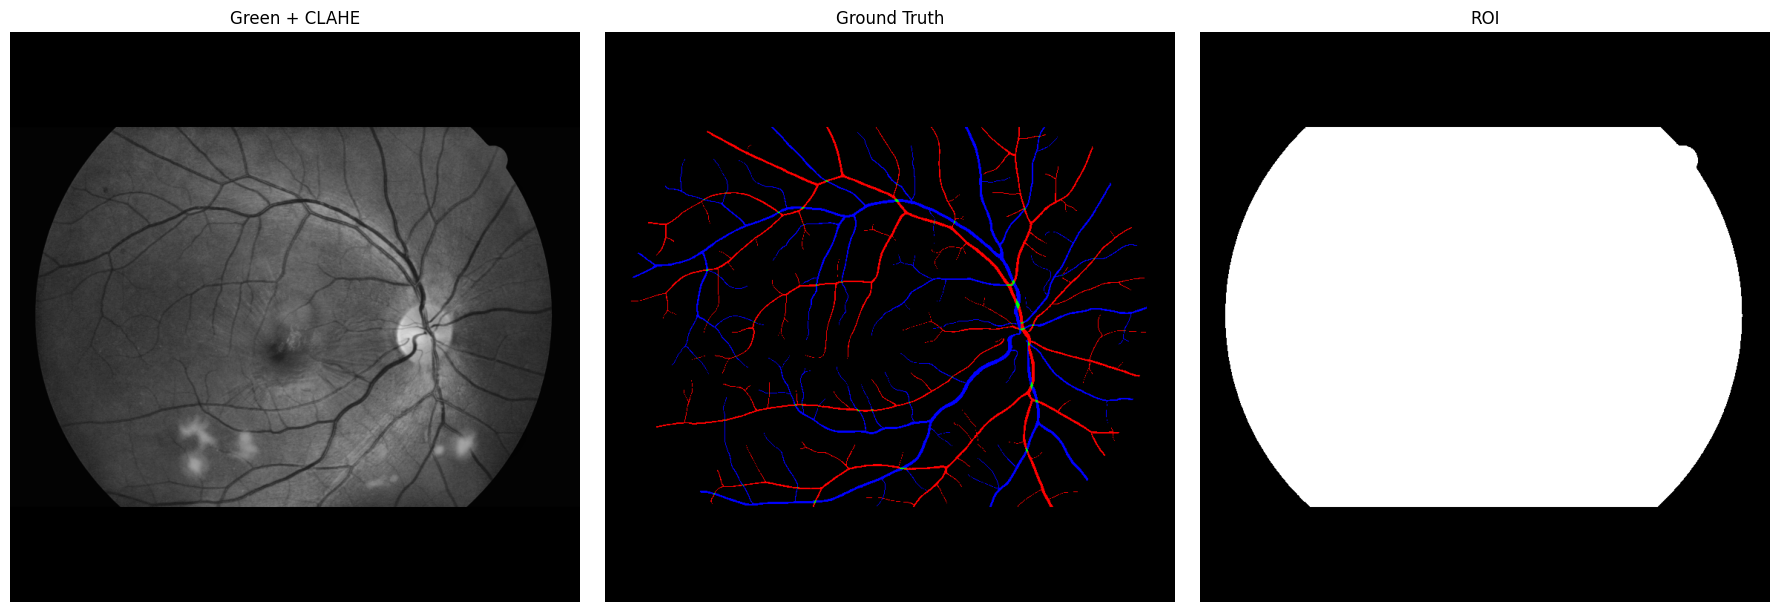

In [12]:
 
# Visual Verification
 

def class_to_rgb(mask):
    """
    Convert class mask back to RGB for visualization only.
    """

    rgb = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)

    rgb[mask == 0] = [0, 0, 0]         # Background
    rgb[mask == 1] = [255, 0, 0]       # Artery
    rgb[mask == 2] = [0, 255, 0]       # Overlap
    rgb[mask == 3] = [0, 0, 255]       # Vein

    return rgb


sample = sorted(glob(os.path.join(PROCESSED_DIR, "train/images/*")))[0]

name = os.path.basename(sample)

image = cv2.imread(sample)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

gt = cv2.imread(
    os.path.join(PROCESSED_DIR, "train/av", name),
    cv2.IMREAD_GRAYSCALE
)

roi = cv2.imread(
    os.path.join(PROCESSED_DIR, "train/masks", name),
    cv2.IMREAD_GRAYSCALE
)

gt_rgb = class_to_rgb(gt)

plt.figure(figsize=(18,6))

plt.subplot(131)
plt.imshow(image)
plt.title("Green + CLAHE")
plt.axis("off")

plt.subplot(132)
plt.imshow(gt_rgb)
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(133)
plt.imshow(roi, cmap="gray")
plt.title("ROI")
plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
# =============================================================================
# Vessel-aware Patch Extraction
# =============================================================================
#
# Retinal fundus images are over 90% background, so extracting every patch on
# the grid spends most of the training compute on empty regions. A patch is
# kept only if it holds enough vessel pixels and sits inside the retinal ROI.
# A small random share of rejected patches is retained so the model still sees
# plain background and does not over-predict vessels in empty areas.

PATCH_DIR = os.path.join(OUTPUT_DIR, "patches")

if os.path.exists(PATCH_DIR):
    shutil.rmtree(PATCH_DIR)

for split in ["train", "val", "test"]:
    for f in ["images", "av", "masks"]:
        os.makedirs(os.path.join(PATCH_DIR, split, f), exist_ok=True)


def extract_patches(split):

    imgs = sorted(glob(os.path.join(PROCESSED_DIR, split, "images/*")))
    gts  = sorted(glob(os.path.join(PROCESSED_DIR, split, "av/*")))
    rois = sorted(glob(os.path.join(PROCESSED_DIR, split, "masks/*")))

    assert len(imgs) == len(gts) == len(rois), f"Mismatch in {split}"

    # Dedicated stream so the filter is reproducible and does not disturb
    # the global random state
    rng = random.Random(SEED)

    examined = 0
    kept = 0
    background_kept = 0

    for ip, gp, rp in tqdm(zip(imgs, gts, rois), total=len(imgs), desc=split):

        img = cv2.imread(ip)
        gt  = cv2.imread(gp, cv2.IMREAD_GRAYSCALE)
        roi = cv2.imread(rp, cv2.IMREAD_GRAYSCALE)

        base = Path(ip).stem

        for y in range(0, IMAGE_SIZE - PATCH_SIZE + 1, PATCH_STRIDE):
            for x in range(0, IMAGE_SIZE - PATCH_SIZE + 1, PATCH_STRIDE):

                examined += 1

                gt_patch  = gt[y:y + PATCH_SIZE, x:x + PATCH_SIZE]
                roi_patch = roi[y:y + PATCH_SIZE, x:x + PATCH_SIZE]

                if ENABLE_VESSEL_PATCHING:

                    vessel_fraction = (gt_patch > 0).mean()
                    roi_fraction = (roi_patch > 0).mean()

                    vessel_rich = (
                        vessel_fraction >= MIN_VESSEL_FRACTION
                        and roi_fraction >= MIN_ROI_FRACTION
                    )

                    if not vessel_rich:

                        if rng.random() >= BACKGROUND_KEEP_RATIO:
                            continue

                        background_kept += 1

                name = f"{base}_y{y}_x{x}.png"

                cv2.imwrite(
                    os.path.join(PATCH_DIR, split, "images", name),
                    img[y:y + PATCH_SIZE, x:x + PATCH_SIZE]
                )
                cv2.imwrite(
                    os.path.join(PATCH_DIR, split, "av", name),
                    gt_patch
                )
                cv2.imwrite(
                    os.path.join(PATCH_DIR, split, "masks", name),
                    roi_patch
                )

                kept += 1

    print(f"{split}: kept {kept} of {examined} candidate patches "
          f"({kept - background_kept} vessel-rich, "
          f"{background_kept} background retained)")


extract_patches("train")

train: 100%|██████████| 34/34 [00:03<00:00, 10.80it/s]

train: kept 589 of 850 candidate patches (578 vessel-rich, 11 background retained)


In [14]:
 
# Create Augmented Dataset
 

AUGMENTED_DIR = "./Augmented_Dataset"

folders = [
    "train/images",
    "train/av",
    "train/masks",

    "val/images",
    "val/av",
    "val/masks",

    "test/images",
    "test/av",
    "test/masks"
]

if os.path.exists(AUGMENTED_DIR):
    shutil.rmtree(AUGMENTED_DIR)

for folder in folders:
    os.makedirs(os.path.join(AUGMENTED_DIR, folder), exist_ok=True)

print("Augmented dataset folders created.")

Augmented dataset folders created.


In [15]:
 
# Copy Validation and Test Sets
 

for split in ["val", "test"]:

    for folder in ["images", "av", "masks"]:

        src = os.path.join(PROCESSED_DIR, split, folder)
        dst = os.path.join(AUGMENTED_DIR, split, folder)

        for file in os.listdir(src):

            shutil.copy(
                os.path.join(src, file),
                os.path.join(dst, file)
            )

print("Validation and Test copied.")

Validation and Test copied.


In [16]:
def _rot(deg):
    return A.Rotate(limit=(deg, deg), border_mode=cv2.BORDER_CONSTANT,
                    interpolation=cv2.INTER_LINEAR,
                    mask_interpolation=cv2.INTER_NEAREST,
                    fill=0, fill_mask=0, p=1)

augmentations = {
    "hflip":        A.HorizontalFlip(p=1),
    "vflip":        A.VerticalFlip(p=1),
    "hvflip":       A.Compose([A.HorizontalFlip(p=1), A.VerticalFlip(p=1)]),
    "rot_p15":      _rot(15),
    "rot_m15":      _rot(-15),
    "rot_p25":      _rot(25),
    "rot_m25":      _rot(-25),
    "rot_p30":      _rot(30),
    "rot_m30":      _rot(-30),
    "hflip_rot20":  A.Compose([A.HorizontalFlip(p=1), _rot(20)]),
    "vflip_rot_m20":A.Compose([A.VerticalFlip(p=1), _rot(-20)]),

    "affine":       A.Affine(scale=(0.8, 1.15), translate_percent=(-0.05, 0.05),
                             shear=(-8, 8), interpolation=cv2.INTER_LINEAR,
                             mask_interpolation=cv2.INTER_NEAREST,
                             border_mode=cv2.BORDER_CONSTANT, fill=0, fill_mask=0, p=1),
    "elastic":      A.ElasticTransform(alpha=40, sigma=6,
                                       interpolation=cv2.INTER_LINEAR,
                                       mask_interpolation=cv2.INTER_NEAREST,
                                       border_mode=cv2.BORDER_CONSTANT,
                                       fill=0, fill_mask=0, p=1),

    "brightness":   A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1),
    "gamma":        A.RandomGamma(gamma_limit=(80, 120), p=1),
    "gaussian_blur":A.GaussianBlur(blur_limit=(3, 5), p=1),
    "gaussian_noise":A.GaussNoise(std_range=(0.02, 0.08), mean_range=(0.0, 0.0),
                                  per_channel=False, p=1),
}

# Register ROI as an additional mask target
augmentations = {
    k: A.Compose(
        v.transforms if isinstance(v, A.Compose) else [v],
        additional_targets={"roi": "mask"}
    )
    for k, v in augmentations.items()
}

In [17]:
 
# Copy Original Training Set
 
for folder in ["images", "av", "masks"]:

    src = os.path.join(PATCH_DIR, "train", folder)
    dst = os.path.join(AUGMENTED_DIR, "train", folder)

    for file in os.listdir(src):

        shutil.copy2(
            os.path.join(src, file),
            os.path.join(dst, file)
        )

print("Original training images copied.")

Original training images copied.


In [18]:
# Offline Augmentation

train_images = sorted(glob(os.path.join(PATCH_DIR, "train/images/*")))
train_gt = sorted(glob(os.path.join(PATCH_DIR, "train/av/*")))
train_roi = sorted(glob(os.path.join(PATCH_DIR, "train/masks/*")))

assert len(train_images) == len(train_gt) == len(train_roi), \
    "Mismatch between images, AV masks and ROI masks."

INTENSITY_AUGS = {
    "brightness",
    "gamma",
    "gaussian_blur",
    "gaussian_noise"
}

for img_path, gt_path, roi_path in tqdm(
    zip(train_images, train_gt, train_roi),
    total=len(train_images)
):

    # Read image (RGB)
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Read masks
    gt = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE)
    roi = cv2.imread(roi_path, cv2.IMREAD_GRAYSCALE)

    base = Path(img_path).stem

    for aug_name, aug in augmentations.items():

        # Intensity-only augmentations
        if aug_name in INTENSITY_AUGS:

            augmented = aug(image=image)

            aug_image = augmented["image"]
            aug_gt = gt.copy()
            aug_roi = roi.copy()

        # Geometric augmentations
        else:

            augmented = aug(
                image=image,
                mask=gt,
                roi=roi
            )

            aug_image = augmented["image"]
            aug_gt = augmented["mask"]
            aug_roi = augmented["roi"]

        filename = f"{base}_{aug_name}.png"

        cv2.imwrite(
            os.path.join(AUGMENTED_DIR, "train/images", filename),
            cv2.cvtColor(aug_image, cv2.COLOR_RGB2BGR)
        )

        cv2.imwrite(
            os.path.join(AUGMENTED_DIR, "train/av", filename),
            aug_gt
        )

        cv2.imwrite(
            os.path.join(AUGMENTED_DIR, "train/masks", filename),
            aug_roi
        )

print("Offline augmentation completed.")

100%|██████████| 589/589 [00:31<00:00, 18.68it/s]


Offline augmentation completed.


In [19]:
# Dataset Statistics

for split in ["train", "val", "test"]:

    n_images = len(glob(os.path.join(AUGMENTED_DIR, split, "images", "*")))
    n_gt = len(glob(os.path.join(AUGMENTED_DIR, split, "av", "*")))
    n_roi = len(glob(os.path.join(AUGMENTED_DIR, split, "masks", "*")))

    assert n_images == n_gt == n_roi, \
        f"{split}: Dataset mismatch ({n_images}, {n_gt}, {n_roi})"

    print(f"{split:5s} : {n_images:4d} samples")

print("\nDataset verification completed successfully.")

train : 10602 samples
val   :    8 samples
test  :    8 samples

Dataset verification completed successfully.


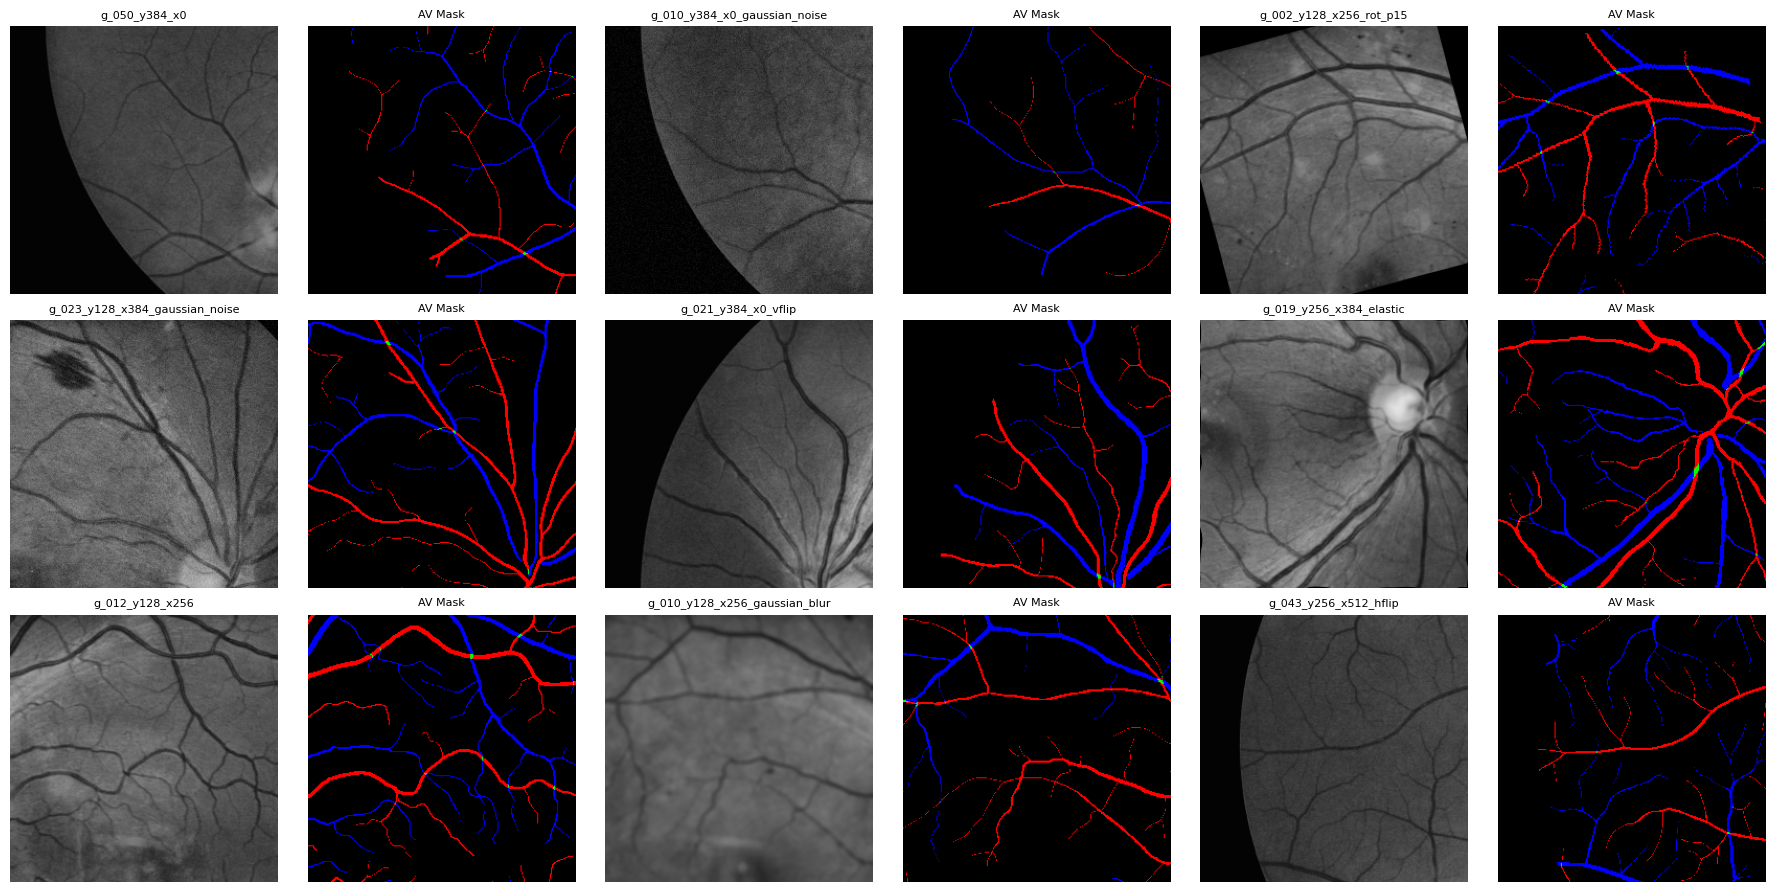

In [20]:
# Visualize Augmentations

samples = random.sample(
    sorted(glob(os.path.join(AUGMENTED_DIR, "train/images/*"))),
    9
)

fig, axes = plt.subplots(3, 6, figsize=(18, 9))

for i, img_path in enumerate(samples):

    base = Path(img_path).name

    gt_path = os.path.join(AUGMENTED_DIR, "train/av", base)

    # RGB image
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # AV mask
    gt = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE)

    axes[i // 3, (i % 3) * 2].imshow(image)
    axes[i // 3, (i % 3) * 2].set_title(Path(img_path).stem, fontsize=8)
    axes[i // 3, (i % 3) * 2].axis("off")

    axes[i // 3, (i % 3) * 2 + 1].imshow(class_to_rgb(gt))
    axes[i // 3, (i % 3) * 2 + 1].set_title("AV Mask", fontsize=8)
    axes[i // 3, (i % 3) * 2 + 1].axis("off")

plt.tight_layout()
plt.show()

In [21]:
# Dataset Class

class RetinalDataset(Dataset):

    def __init__(self, image_dir, mask_dir, compute_weights=False):

        self.images = sorted(glob(os.path.join(image_dir, "*")))
        self.masks  = sorted(glob(os.path.join(mask_dir, "*")))

        assert len(self.images) == len(self.masks), \
            "Mismatch between images and masks."

        self.weights = None

        if compute_weights:

            w = []

            for m in tqdm(self.masks, desc="Computing sample weights"):

                gt = cv2.imread(m, cv2.IMREAD_GRAYSCALE)

                vessel  = (gt > 0).mean()
                overlap = (gt == 2).mean()

                w.append(
                    max(vessel, WEIGHT_FLOOR) ** 0.5
                    + OVERLAP_BOOST * (overlap ** 0.5)
                )

            self.weights = np.array(w, dtype=np.float64)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image = cv2.imread(self.images[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(self.masks[idx], cv2.IMREAD_GRAYSCALE)

        image = image.astype(np.float32) / 255.0
        image = np.transpose(image, (2, 0, 1))

        image = torch.from_numpy(image).float()
        mask  = torch.from_numpy(mask).long()

        return image, mask

In [22]:
 
# DataLoaders
 

from torch.utils.data import WeightedRandomSampler

train_dataset = RetinalDataset(
    os.path.join(AUGMENTED_DIR, "train/images"),
    os.path.join(AUGMENTED_DIR, "train/av"),
    compute_weights=True
)

val_dataset = RetinalDataset(

    os.path.join(AUGMENTED_DIR, "val/images"),
    os.path.join(AUGMENTED_DIR, "val/av")

)

test_dataset = RetinalDataset(

    os.path.join(AUGMENTED_DIR, "test/images"),
    os.path.join(AUGMENTED_DIR, "test/av")

)

sampler = WeightedRandomSampler(
    weights=torch.from_numpy(train_dataset.weights),
    num_samples=len(train_dataset),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0
)

print("Train :", len(train_dataset))
print("Validation :", len(val_dataset))
print("Test :", len(test_dataset))

Computing sample weights: 100%|██████████| 10602/10602 [00:35<00:00, 300.32it/s]

Train : 10602
Validation : 8
Test : 8


In [23]:
w = train_dataset.weights

print("Weight percentiles [0,25,50,75,100]:")
print(np.percentile(w, [0, 25, 50, 75, 100]))
print(f"Max/Min ratio : {w.max() / w.min():.1f}x")
print(f"Effective unique samples : {(w.sum()**2)/(w**2).sum():.0f} / {len(w)}")

Weight percentiles [0,25,50,75,100]:
[0.10305395 0.26334011 0.31792739 0.38423809 0.57232739]
Max/Min ratio : 5.6x
Effective unique samples : 9948 / 10602


In [24]:
# Verify Dataset

images, masks = next(iter(train_loader))

print("Images Shape :", images.shape)
print("Masks Shape  :", masks.shape)

print("Image dtype  :", images.dtype)
print("Mask dtype   :", masks.dtype)

print("Image Range  :", images.min().item(), "to", images.max().item())

print("Unique Classes :", torch.unique(masks))

Images Shape : torch.Size([8, 3, 256, 256])
Masks Shape  : torch.Size([8, 256, 256])
Image dtype  : torch.float32
Mask dtype   : torch.int64
Image Range  : 0.0 to 0.8980392217636108
Unique Classes : tensor([0, 1, 2, 3])


In [25]:
# Double Convolution Block
 
import math
class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        groups = math.gcd(8, out_channels)

        self.conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                groups,
                out_channels
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                groups,
                out_channels
            ),

            nn.ReLU(inplace=True)

        )

    def forward(self, x):

        return self.conv(x)

In [26]:
# Attention Gate

class AttentionBlock(nn.Module):

    def __init__(self, F_g, F_l, F_int):

        super().__init__()


        groups = math.gcd(8, F_int)

        self.W_g = nn.Sequential(

            nn.Conv2d(
                F_g,
                F_int,
                kernel_size=1,
                bias=True
            ),

            nn.GroupNorm(
                groups,
                F_int
            )

        )

        self.W_x = nn.Sequential(

            nn.Conv2d(
                F_l,
                F_int,
                kernel_size=1,
                bias=True
            ),

            nn.GroupNorm(
                groups,
                F_int
            )

        )

        self.psi = nn.Sequential(

            nn.Conv2d(
                F_int,
                1,
                kernel_size=1,
                bias=True
            ),

            nn.Sigmoid()

        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):

        g1 = self.W_g(g)

        x1 = self.W_x(x)

        psi = self.relu(g1 + x1)

        psi = self.psi(psi)

        return x * psi

In [27]:
# Encoder Block

class EncoderBlock(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.conv = DoubleConv(in_channels, out_channels)

        self.pool = nn.MaxPool2d(2)

    def forward(self, x):

        skip = self.conv(x)

        pooled = self.pool(skip)

        return skip, pooled

In [28]:
# Decoder Block

class DecoderBlock(nn.Module):

    def __init__(self, in_channels, skip_channels, out_channels):

        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.attention = AttentionBlock(
            F_g=out_channels,
            F_l=skip_channels,
            F_int=out_channels // 2
        )

        self.conv = DoubleConv(
            out_channels + skip_channels,
            out_channels
        )

    def forward(self, x, skip):

        x = self.up(x)

        skip = self.attention(x, skip)

        x = torch.cat([skip, x], dim=1)

        return self.conv(x)

In [29]:
# Attention U-Net with Deep Supervision

class AttentionUNet(nn.Module):

    def __init__(self, in_channels=3, num_classes=4):

        super().__init__()

        # Encoder

        self.enc1 = EncoderBlock(in_channels, 64)
        self.enc2 = EncoderBlock(64, 128)
        self.enc3 = EncoderBlock(128, 256)
        self.enc4 = EncoderBlock(256, 512)

        # Bottleneck

        self.bottleneck = DoubleConv(512, 1024)

        # Decoder

        self.dec4 = DecoderBlock(1024, 512, 512)
        self.dec3 = DecoderBlock(512, 256, 256)
        self.dec2 = DecoderBlock(256, 128, 128)
        self.dec1 = DecoderBlock(128, 64, 64)
        


        # Main Output

        self.out = nn.Conv2d(
            64,
            num_classes,
            kernel_size=1
        )

        # Deep Supervision Heads

        self.ds4 = nn.Conv2d(
            512,
            num_classes,
            kernel_size=1
        )

        self.ds3 = nn.Conv2d(
            256,
            num_classes,
            kernel_size=1
        )

        self.ds2 = nn.Conv2d(
            128,
            num_classes,
            kernel_size=1
        )
        
        self.initialize_weights()
        
    def initialize_weights(self):

        for m in self.modules():

            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(
                    m.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )

                if m.bias is not None:
                    nn.init.zeros_(m.bias)

            elif isinstance(m, nn.GroupNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):

        # Encoder

        s1, p1 = self.enc1(x)

        s2, p2 = self.enc2(p1)

        s3, p3 = self.enc3(p2)

        s4, p4 = self.enc4(p3)

        # Bottleneck

        b = self.bottleneck(p4)

        # Decoder

        d4 = self.dec4(b, s4)

        d3 = self.dec3(d4, s3)

        d2 = self.dec2(d3, s2)

        d1 = self.dec1(d2, s1)

        # Main Prediction

        out = self.out(d1)

        # Deep Supervision

        aux4 = self.ds4(d4)

        aux3 = self.ds3(d3)

        aux2 = self.ds2(d2)

        

        return (

    out,

    F.interpolate(
        aux2,
        size=out.shape[2:],
        mode="bilinear",
        align_corners=False
    ),
    

    F.interpolate(
        aux3,
        size=out.shape[2:],
        mode="bilinear",
        align_corners=False
    ),

    F.interpolate(
        aux4,
        size=out.shape[2:],
        mode="bilinear",
        align_corners=False
    )
    
    

)

In [30]:
model = AttentionUNet(
    in_channels=3,
    num_classes=NUM_CLASSES
).to(DEVICE)

print(f"Model Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Model Parameters: 31,392,948
Trainable Parameters: 31,392,948


In [31]:
# Multi-Class Focal Tversky Loss

class FocalTverskyLoss(nn.Module):

    def __init__(
        self,
        alpha=ALPHA,
        beta=BETA,
        gamma=GAMMA,
        smooth=1e-6,
        num_classes=NUM_CLASSES
    ):
        super().__init__()

        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.smooth = smooth
        self.num_classes = num_classes

    def forward(self, logits, targets):

        # Convert logits to probabilities
        probs = torch.softmax(logits, dim=1)

        # Convert targets to one-hot encoding
        targets_onehot = F.one_hot(
            targets,
            self.num_classes
        ).permute(0, 3, 1, 2).float()

        # Flatten spatial dimensions
        probs = probs.flatten(2)
        targets_onehot = targets_onehot.flatten(2)

        # Compute Tversky statistics
        TP = (probs * targets_onehot).sum(dim=2)
        FP = (probs * (1 - targets_onehot)).sum(dim=2)
        FN = ((1 - probs) * targets_onehot).sum(dim=2)

        tversky = (
            TP + self.smooth
        ) / (
            TP +
            self.alpha * FP +
            self.beta * FN +
            self.smooth
        )

        focal_tversky = (1.0 - tversky) ** self.gamma

        return focal_tversky.mean()

In [32]:
 # Soft Skeletonization
 
def soft_erode(img):

    if img.dim() == 4:

        p1 = -F.max_pool2d(-img, (3,1), stride=1, padding=(1,0))

        p2 = -F.max_pool2d(-img, (1,3), stride=1, padding=(0,1))

        return torch.min(p1, p2)

    raise ValueError("Expected 4D tensor")


def soft_dilate(img):

    return F.max_pool2d(
        img,
        kernel_size=3,
        stride=1,
        padding=1
    )


def soft_open(img):

    return soft_dilate(
        soft_erode(img)
    )


def soft_skeletonize(img, iterations=CLDICE_ITERATIONS):

    img1 = soft_open(img)

    skeleton = F.relu(img - img1)

    for _ in range(iterations):

        img = soft_erode(img)

        opened = soft_open(img)

        delta = F.relu(img-opened)

        skeleton = skeleton + F.relu(delta - skeleton*delta)

    return skeleton

In [33]:
# Multi-Class CLDice Loss

class CLDiceLoss(nn.Module):

    def __init__(
        self,
        num_classes=NUM_CLASSES,
        iterations=CLDICE_ITERATIONS,
        smooth=1e-6
    ):

        super().__init__()

        self.num_classes = num_classes
        self.iterations = iterations
        self.smooth = smooth

    def forward(self, logits, targets):

        probs = torch.softmax(logits, dim=1)
        
        # Ignore background channel
        probs = probs[:, 1:, :, :]

        targets = F.one_hot(
            targets,
            self.num_classes
        ).permute(0,3,1,2).float()

        targets = targets[:, 1:, :, :]
        
        skel_pred = soft_skeletonize(
            probs,
            self.iterations
        )

        skel_gt = soft_skeletonize(
            targets,
            self.iterations
        )

        tprec = (

            (skel_pred * targets).sum((2,3))

            + self.smooth

        ) / (

            skel_pred.sum((2,3))

            + self.smooth

        )

        tsens = (

            (skel_gt * probs).sum((2,3))

            + self.smooth

        ) / (

            skel_gt.sum((2,3))

            + self.smooth

        )

        cldice = (

            2*tprec*tsens

        ) / (

            tprec + tsens + self.smooth

        )

        return 1 - cldice.mean()

In [34]:
focal_tversky_loss = FocalTverskyLoss(
    alpha=ALPHA,
    beta=BETA,
    gamma=GAMMA,
    num_classes=NUM_CLASSES
)

cldice_loss = CLDiceLoss(
    num_classes=NUM_CLASSES,
    iterations=CLDICE_ITERATIONS
)

In [35]:
# Hybrid Loss with clDice warmup
# Weights and start epoch come from the configuration cell.

def hybrid_loss(outputs, targets, epoch=0):
    main, aux2, aux3, aux4 = outputs

    ft_main = focal_tversky_loss(main, targets)

    if epoch >= CLDICE_START_EPOCH:
        with torch.amp.autocast("cuda", enabled=False):
            cl_main = cldice_loss(main.float(), targets)
        main_loss = (
            FOCAL_TVERSKY_WEIGHT * ft_main
            + CLDICE_WEIGHT * cl_main
        )
    else:
        main_loss = ft_main

    aux2_loss = focal_tversky_loss(aux2, targets)
    aux3_loss = focal_tversky_loss(aux3, targets)
    aux4_loss = focal_tversky_loss(aux4, targets)

    return main_loss + 0.40*aux2_loss + 0.25*aux3_loss + 0.15*aux4_loss

In [36]:
# Optimizer

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY

)

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=20,
    T_mult=1,
    eta_min=1e-6

)

scaler = torch.amp.GradScaler("cuda")
print("Optimizer, Scheduler and AMP initialized.")

Optimizer, Scheduler and AMP initialized.


In [37]:
@torch.no_grad()
def dice_score(
    preds,
    targets,
    num_classes=NUM_CLASSES,
    ignore_background=True,
    smooth=1e-6
):

    preds = torch.argmax(preds, dim=1)

    dice_scores = []

    start_class = 1 if ignore_background else 0

    for cls in range(start_class, num_classes):

        pred_cls = (preds == cls).float()
        target_cls = (targets == cls).float()

        # A class absent from both prediction and target is undefined, not
        # perfect. Scoring it 1.0 inflates the mean, which matters most for
        # the rare overlap class.
        if target_cls.sum() == 0 and pred_cls.sum() == 0:
            dice_scores.append(
                torch.tensor(float("nan"), device=preds.device)
            )
            continue

        intersection = (pred_cls * target_cls).sum()
        union = pred_cls.sum() + target_cls.sum()

        dice = (2.0 * intersection + smooth) / (union + smooth)

        dice_scores.append(dice)

    dice_scores = torch.stack(dice_scores)

    mean_dice = torch.nanmean(dice_scores).item()

    return mean_dice, dice_scores.cpu().tolist()

In [38]:
@torch.no_grad()
def iou_score(
    preds,
    targets,
    num_classes=NUM_CLASSES,
    ignore_background=True,
    smooth=1e-6
):

    preds = torch.argmax(preds, dim=1)

    iou_scores = []

    start_class = 1 if ignore_background else 0

    for cls in range(start_class, num_classes):

        pred_cls = (preds == cls).float()
        target_cls = (targets == cls).float()

        # A class absent from both prediction and target is undefined, not
        # perfect. Scoring it 1.0 inflates the mean, which matters most for
        # the rare overlap class.
        if target_cls.sum() == 0 and pred_cls.sum() == 0:
            iou_scores.append(
                torch.tensor(float("nan"), device=preds.device)
            )
            continue

        intersection = (pred_cls * target_cls).sum()
        union = pred_cls.sum() + target_cls.sum() - intersection

        iou = (intersection + smooth) / (union + smooth)

        iou_scores.append(iou)

    iou_scores = torch.stack(iou_scores)

    mean_iou = torch.nanmean(iou_scores).item()

    return mean_iou, iou_scores.cpu().tolist()

In [39]:
# Precision, Recall, F1 and Accuracy

from sklearn.metrics import (
    precision_recall_fscore_support,
    accuracy_score
)

CLASS_NAMES = [
    "Background",
    "Artery",
    "Overlap",
    "Vein"
]


@torch.no_grad()
def classification_metrics(preds, targets):

    preds = preds.detach()
    preds = torch.argmax(preds, dim=1)
    preds = preds.cpu().numpy().ravel()

    targets = targets.detach().cpu().numpy().ravel()

    precision, recall, f1, _ = precision_recall_fscore_support(
        targets,
        preds,
        labels=[0, 1, 2, 3],
        average=None,
        zero_division=0
    )

    accuracy = accuracy_score(
        targets,
        preds
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

In [40]:
# Train One Epoch

def train_one_epoch(
    model,
    loader,
    optimizer,
    scaler,
    device,
    epoch=0
):

    model.train()

    running_loss = 0.0

    # Collected rather than summed: a batch where a class is absent from both
    # prediction and target yields nan for that class, which must not poison
    # the epoch mean.
    dice_values = []
    iou_values = []

    progress = tqdm(loader)

    for images, masks in progress:

        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda"):

            outputs = model(images)

            loss = hybrid_loss(
                outputs,
                masks,
                epoch
            )

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        # Main prediction only
        main_output = outputs[0]

        dice, _ = dice_score(
            main_output,
            masks
        )

        iou, _ = iou_score(
            main_output,
            masks
        )

        running_loss += float(loss.detach())

        dice_values.append(dice)
        iou_values.append(iou)

        progress.set_postfix(
            Loss=f"{float(loss.detach()):.4f}",
            Dice=f"{dice:.4f}",
            IoU=f"{iou:.4f}"
        )

    return (
        running_loss / len(loader),
        float(np.nanmean(dice_values)),
        float(np.nanmean(iou_values))
    )

In [41]:
# Validate One Epoch

def validate_one_epoch(
    model,
    loader,
    device,
    epoch=0
):

    model.eval()

    running_loss = 0.0

    dice_values = []
    iou_values = []

    running_acc = 0.0
    running_precision = np.zeros(NUM_CLASSES)
    running_recall = np.zeros(NUM_CLASSES)
    running_f1 = np.zeros(NUM_CLASSES)

    with torch.no_grad():

        progress = tqdm(loader)

        for images, masks in progress:

            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            with torch.amp.autocast("cuda"):

                outputs = model(images)

                loss = hybrid_loss(
                    outputs,
                    masks,
                    epoch
                )

            # Main prediction only
            main_output = outputs[0]

            dice, _ = dice_score(
                main_output,
                masks
            )

            iou, _ = iou_score(
                main_output,
                masks
            )

            metrics = classification_metrics(
                main_output,
                masks
            )

            running_loss += float(loss.detach())

            dice_values.append(dice)
            iou_values.append(iou)

            running_acc += metrics["accuracy"]
            running_precision += metrics["precision"]
            running_recall += metrics["recall"]
            running_f1 += metrics["f1"]

            progress.set_postfix(
                Loss=f"{float(loss.detach()):.4f}",
                Dice=f"{dice:.4f}",
                IoU=f"{iou:.4f}"
            )

    n = len(loader)

    return (
        running_loss / n,
        float(np.nanmean(dice_values)),
        float(np.nanmean(iou_values)),
        running_acc / n,
        running_precision / n,
        running_recall / n,
        running_f1 / n
    )

In [42]:
model.eval()

with torch.no_grad():

    images, masks = next(iter(train_loader))
    images = images.to(DEVICE, non_blocking=True)

    outputs = model(images)

    print(f"Output type : {type(outputs)}")
    print(f"Number of outputs : {len(outputs)}\n")

    for i, out in enumerate(outputs):
        print(f"Output {i}: {tuple(out.shape)}")

del outputs, images, masks
torch.cuda.empty_cache()

Output type : <class 'tuple'>
Number of outputs : 4

Output 0: (8, 4, 256, 256)
Output 1: (8, 4, 256, 256)
Output 2: (8, 4, 256, 256)
Output 3: (8, 4, 256, 256)


In [43]:
# Early Stopping Helper

def early_stopping(
    current_score,
    best_score,
    counter,
    patience
):
    """
    Early stopping based on validation Dice.

    Returns:
        best_score (float)
        counter (int)
        should_stop (bool)
        is_best (bool)
    """

    if current_score > best_score:

        best_score = current_score
        counter = 0

        return best_score, counter, False, True

    counter += 1

    if counter >= patience:
        return best_score, counter, True, False

    return best_score, counter, False, False

In [44]:
# Complete Training Loop

best_dice = 0.0
epochs_without_improvement = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_dice": [],
    "val_dice": [],
    "train_iou": [],
    "val_iou": []
}

for epoch in range(EPOCHS):

    print("=" * 40)
    print(f"Epoch [{epoch + 1}/{EPOCHS}]")
    print("=" * 40)

    train_results = train_one_epoch(
        model,
        train_loader,
        optimizer,
        scaler,
        DEVICE,
        epoch
    )

    val_results = validate_one_epoch(
        model,
        val_loader,
        DEVICE,epoch
    )

    scheduler.step()

    train_loss, train_dice, train_iou = train_results

    (
        val_loss,
        val_dice,
        val_iou,
        val_acc,
        val_prec,
        val_rec,
        val_f1
    ) = val_results

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_dice"].append(train_dice)
    history["val_dice"].append(val_dice)

    history["train_iou"].append(train_iou)
    history["val_iou"].append(val_iou)

    print()
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Dice : {train_dice:.4f}")
    print(f"Train IoU  : {train_iou:.4f}")

    print()
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Dice   : {val_dice:.4f}")
    print(f"Val IoU    : {val_iou:.4f}")

    print()
    print(f"Validation Accuracy : {val_acc:.4f}")

    print("\nPer Class Metrics")

    for i, cls in enumerate(CLASS_NAMES):
        print(
            f"{cls:12s} | "
            f"P={val_prec[i]:.3f} "
            f"R={val_rec[i]:.3f} "
            f"F1={val_f1[i]:.3f}"
        )

    # Early Stopping

    best_dice, epochs_without_improvement, stop, is_best = early_stopping(
        val_dice,
        best_dice,
        epochs_without_improvement,
        EARLY_STOPPING_PATIENCE
    )

    if is_best:

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "best_dice": best_dice,
                "history": history,
            },
            CHECKPOINT_NAME
        )

        print("\nBest model saved.")

    else:

        print(
            f"\nEarly Stopping Counter: "
            f"{epochs_without_improvement}/{EARLY_STOPPING_PATIENCE}"
        )

    if stop:

        print("\nEarly stopping triggered.")
        break

print("\nTraining Complete.")

Epoch [1/200]


100%|██████████| 8/8 [00:01<00:00,  7.74it/s, Dice=0.4633, IoU=0.3315, Loss=0.6007]



Train Loss : 0.8116
Train Dice : 0.3823
Train IoU  : 0.2577

Val Loss   : 0.6456
Val Dice   : 0.4284
Val IoU    : 0.2953

Validation Accuracy : 0.9646

Per Class Metrics
Background   | P=0.993 R=0.977 F1=0.985
Artery       | P=0.395 R=0.724 F1=0.508
Overlap      | P=0.137 R=0.149 F1=0.140
Vein         | P=0.636 R=0.644 F1=0.637

Best model saved.
Epoch [2/200]


100%|██████████| 8/8 [00:00<00:00,  8.52it/s, Dice=0.6040, IoU=0.4451, Loss=0.3976]



Train Loss : 0.5544
Train Dice : 0.5043
Train IoU  : 0.3579

Val Loss   : 0.4784
Val Dice   : 0.5545
Val IoU    : 0.3962

Validation Accuracy : 0.9725

Per Class Metrics
Background   | P=0.992 R=0.984 F1=0.988
Artery       | P=0.521 R=0.703 F1=0.595
Overlap      | P=0.346 R=0.443 F1=0.381
Vein         | P=0.679 R=0.703 F1=0.688

Best model saved.
Epoch [3/200]


...


Train Loss : 0.2339
Train Dice : 0.7670
Train IoU  : 0.6239

Val Loss   : 0.4372
Val Dice   : 0.6062
Val IoU    : 0.4490

Validation Accuracy : 0.9733

Per Class Metrics
Background   | P=0.994 R=0.981 F1=0.987
Artery       | P=0.565 R=0.808 F1=0.662
Overlap      | P=0.504 R=0.376 F1=0.427
Vein         | P=0.668 R=0.810 F1=0.730

Early Stopping Counter: 23/25
Epoch [38/200]


100%|██████████| 8/8 [00:00<00:00,  8.14it/s, Dice=0.6619, IoU=0.5019, Loss=0.3393]



Train Loss : 0.2314
Train Dice : 0.7693
Train IoU  : 0.6271

Val Loss   : 0.4328
Val Dice   : 0.6093
Val IoU    : 0.4518

Validation Accuracy : 0.9735

Per Class Metrics
Background   | P=0.993 R=0.981 F1=0.987
Artery       | P=0.566 R=0.802 F1=0.661
Overlap      | P=0.495 R=0.395 F1=0.436
Vein         | P=0.671 R=0.809 F1=0.731

Early Stopping Counter: 24/25
Epoch [39/200]


100%|██████████| 8/8 [00:00<00:00,  8.16it/s, Dice=0.6620, IoU=0.5019, Loss=0.3404]


Train Loss : 0.2282
Train Dice : 0.7718
Train IoU  : 0.6304

Val Loss   : 0.4331
Val Dice   : 0.6085
Val IoU    : 0.4509

Validation Accuracy : 0.9734

Per Class Metrics
Background   | P=0.994 R=0.981 F1=0.987
Artery       | P=0.567 R=0.803 F1=0.661
Overlap      | P=0.502 R=0.388 F1=0.434
Vein         | P=0.668 R=0.811 F1=0.730

Early Stopping Counter: 25/25

Early stopping triggered.

Training Complete.


In [45]:
# Load Best Checkpoint
#
# The un-augmented baseline is scored inside test_model_tta further down, so it
# is not evaluated separately here. This cell only restores the best weights,
# which the visualisation cell below relies on.

checkpoint = torch.load(
    CHECKPOINT_NAME,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

print(f"Loaded epoch {checkpoint['epoch']} "
      f"(best validation Dice {checkpoint['best_dice']:.4f})")

Loaded epoch 14 (best validation Dice 0.6271)


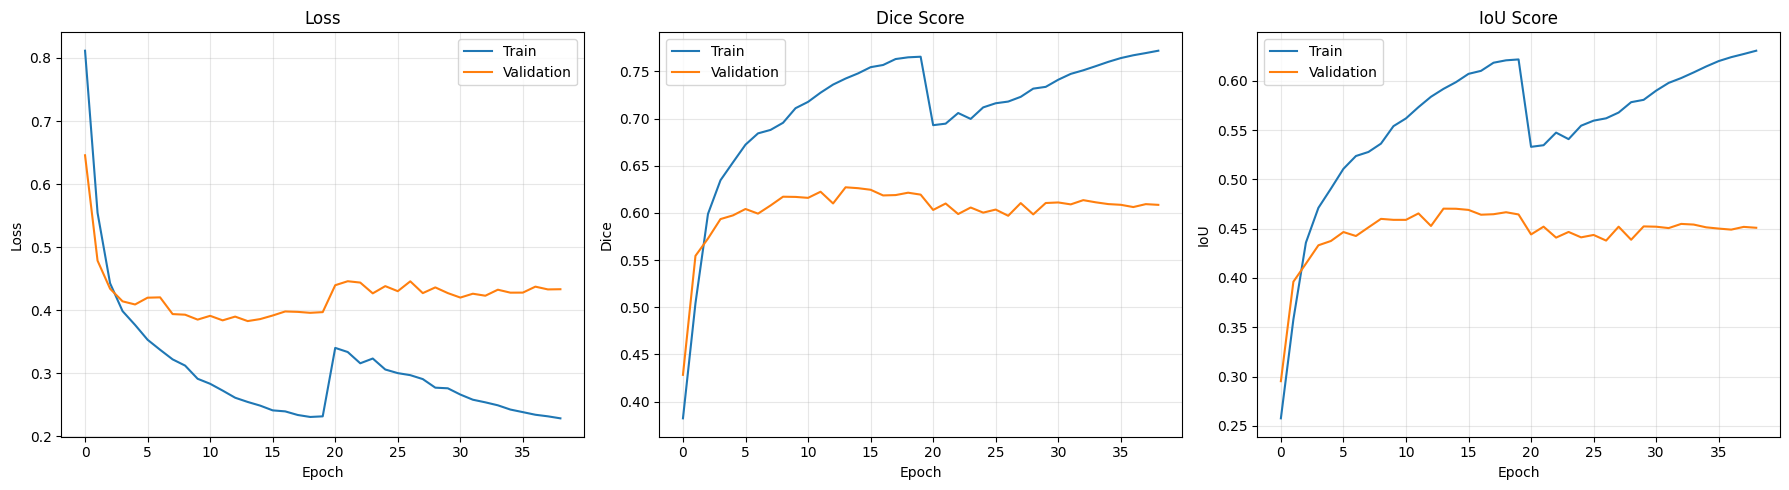

In [46]:
# Training Curves

plt.figure(figsize=(18, 5))

# ---------------- Loss ---------------- #

plt.subplot(1, 3, 1)

plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Validation")

plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()

# ---------------- Dice ---------------- #

plt.subplot(1, 3, 2)

plt.plot(history["train_dice"], label="Train")
plt.plot(history["val_dice"], label="Validation")

plt.title("Dice Score")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.grid(True, alpha=0.3)
plt.legend()

# ---------------- IoU ---------------- #

plt.subplot(1, 3, 3)

plt.plot(history["train_iou"], label="Train")
plt.plot(history["val_iou"], label="Validation")

plt.title("IoU Score")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.grid(True, alpha=0.3)
plt.legend()  

plt.tight_layout()
plt.show()

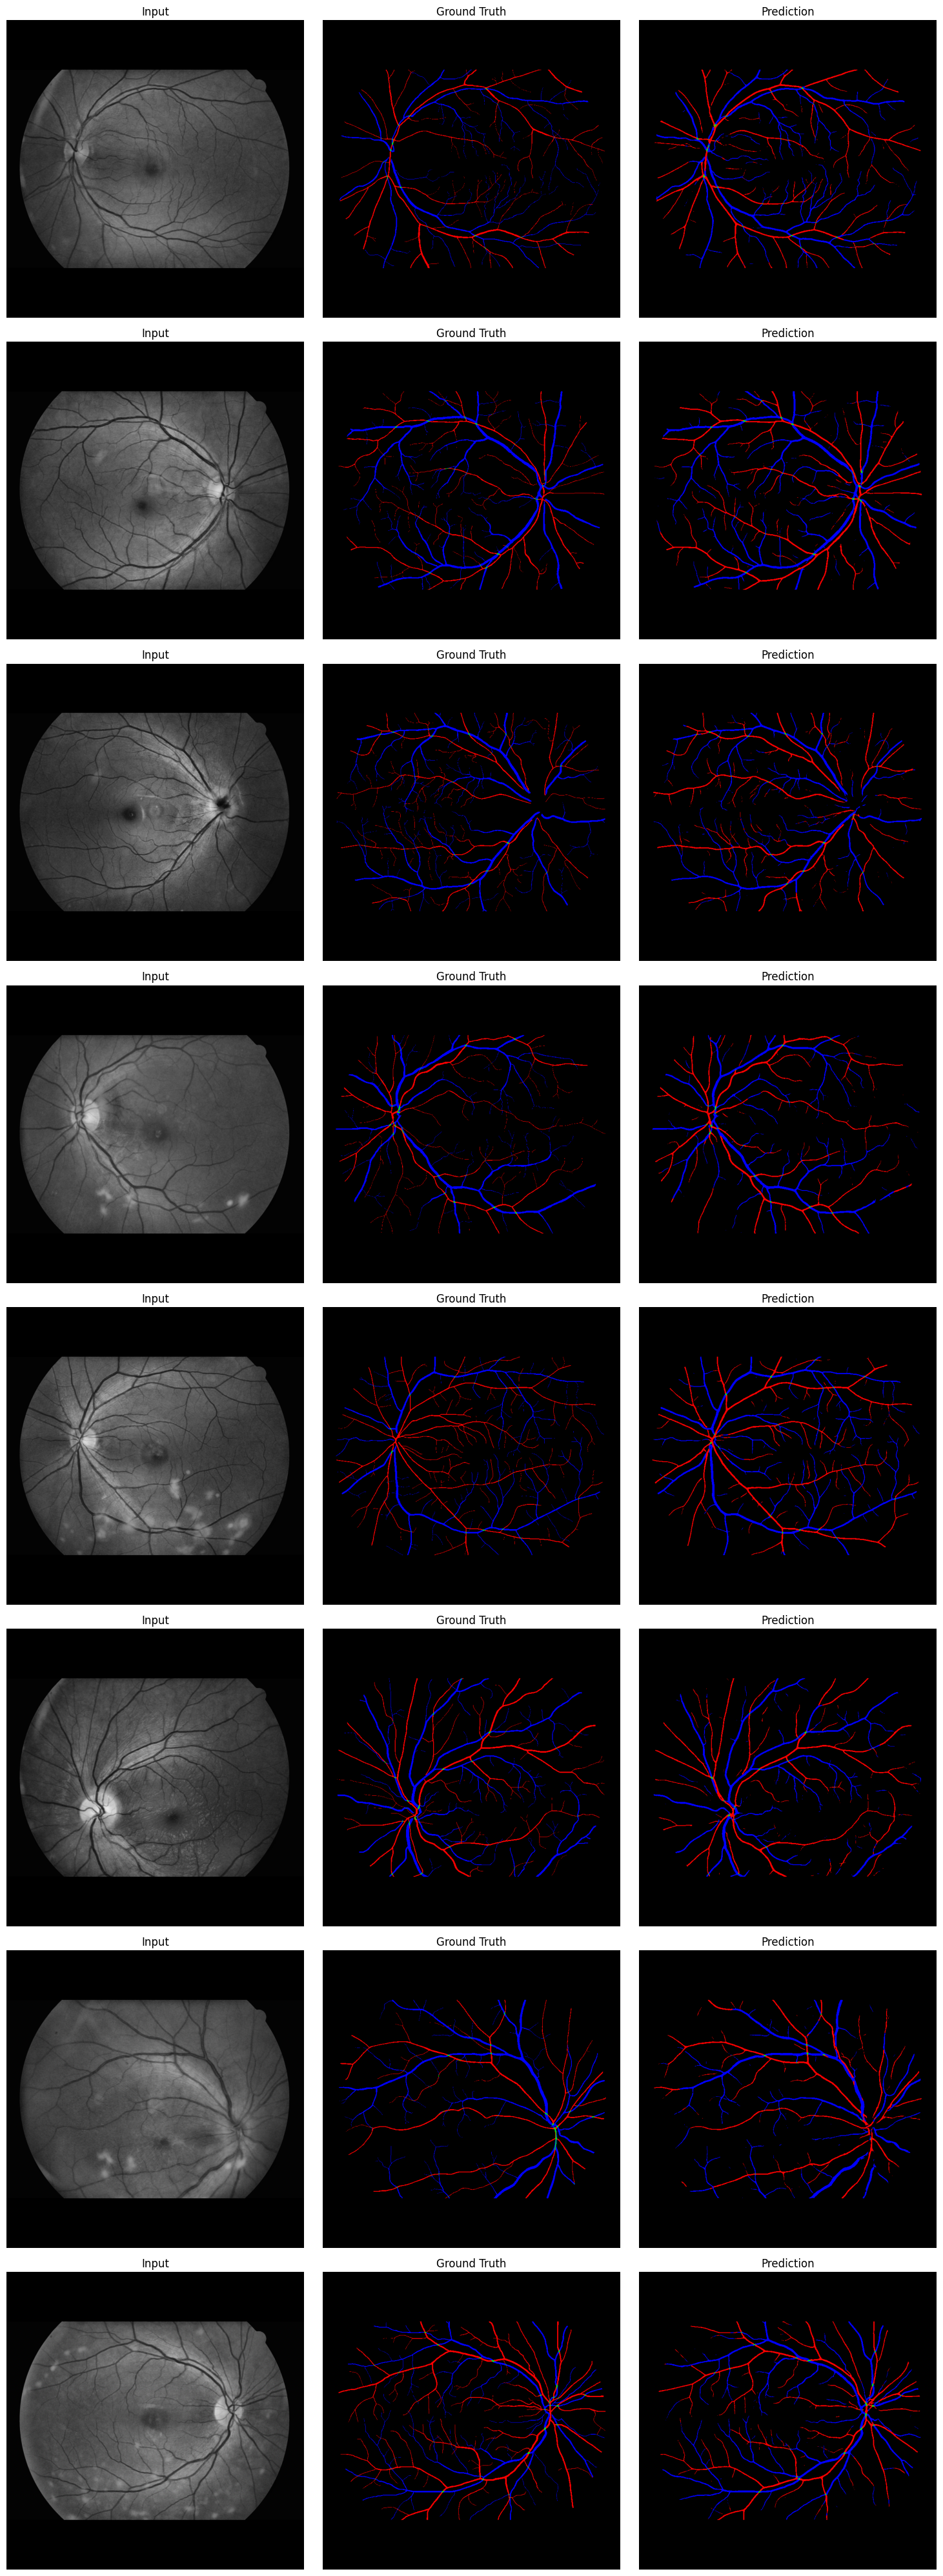

In [47]:
# Visualization

model.eval()

num_examples = 8

indices = np.random.choice(
    len(test_dataset),
    num_examples,
    replace=False
)

plt.figure(figsize=(15, 5 * num_examples))

with torch.no_grad():

    for row, idx in enumerate(indices):

        image, gt = test_dataset[idx]

        image_gpu = image.unsqueeze(0).to(
            DEVICE,
            non_blocking=True
        )

        with torch.amp.autocast("cuda"):

            outputs = model(image_gpu)

        main_output = outputs[0]

        pred = torch.argmax(
            main_output,
            dim=1
        ).squeeze().cpu().numpy()

        gt = gt.numpy()

        pred_rgb = class_to_rgb(pred)
        gt_rgb = class_to_rgb(gt)

        image_rgb = image.permute(1, 2, 0).numpy()

        plt.subplot(num_examples, 3, row * 3 + 1)
        plt.imshow(image_rgb)
        plt.title("Input")
        plt.axis("off")

        plt.subplot(num_examples, 3, row * 3 + 2)
        plt.imshow(gt_rgb)
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(num_examples, 3, row * 3 + 3)
        plt.imshow(pred_rgb)
        plt.title("Prediction")
        plt.axis("off")

plt.tight_layout()
plt.show()

---

# Test-Time Augmentation (TTA)

This notebook is a copy of `4.attention_UNET.ipynb` with a **test-time augmentation**
stage added after training. The training and validation loops are structurally unchanged, but the
Dice and IoU functions were corrected (see below), so absolute scores are
not comparable to notebook 4. The baseline-versus-TTA comparison inside
this notebook is exact, since both are scored by the same code on the
same batches.

## Strategy

**Transform group: D4 (dihedral) x multi-scale**

The 8 elements of the dihedral group `D4` are applied to every input:

| k | Transform |
|---|-----------|
| 0 | identity |
| 1 | rot 90 |
| 2 | rot 180 |
| 3 | rot 270 |
| 4 | hflip |
| 5 | hflip + rot 90 |
| 6 | hflip + rot 180 |
| 7 | hflip + rot 270 |

Flips and 90-degree rotations are **lossless** (pure memory permutations, no
interpolation), so they introduce no resampling error into the prediction.

Each of the 8 transforms is additionally evaluated at **3 scales** (0.75x, 1.0x, 1.25x),
giving **24 forward passes per image**. Multi-scale does involve bilinear
interpolation, which is why the per-scale logits are mapped back to the native
resolution *after* the geometric inverse is applied.

**Merging: two strategies, reported side by side**

1. `tta_prob`: mean of the post-softmax probabilities, then argmax.
   Well-calibrated; a single overconfident view cannot dominate.
2. `tta_logit`: mean of the raw logits, then softmax/argmax.
   Sharper decision boundaries, but sensitive to outlier views.

Both are scored against the un-augmented `baseline` (single forward pass) on the
same test batch so the comparison is exact.

## Notes

- Only the **main** segmentation head is used for TTA. The deep-supervision heads
  (`aux2`, `aux3`, `aux4`) are training-time regularizers and are ignored here.
- Geometric inverse is applied **before** the resize back to native resolution,
  so rotation/flip stay exact and only the scale change costs interpolation.
- Test loss is reported for the baseline only, since `hybrid_loss` needs the full
  4-tuple of deep-supervision outputs which TTA does not produce.
- Dice and IoU skip any class that is absent from both the prediction and the
  ground truth. Previously such a class scored `1e-6 / 1e-6 = 1.0`, which
  silently inflated the mean on the rare overlap class.

---

In [48]:
# =============================================================================
# Test-Time Augmentation Configuration
# =============================================================================

# Dihedral group D4 -- 8 lossless symmetries (no interpolation error)
#   k = 0..3  ->  rot90 applied k times
#   k = 4..7  ->  horizontal flip, then rot90 applied (k - 4) times
TTA_D4_KS = [0, 1, 2, 3, 4, 5, 6, 7]

# Multi-scale factors, applied on top of every D4 transform
TTA_SCALES = [0.75, 1.0, 1.25]

# Encoder has 4 max-pools, so spatial dims must stay divisible by 16
TTA_SIZE_MULTIPLE = 16

TTA_NUM_PASSES = len(TTA_D4_KS) * len(TTA_SCALES)

print("=" * 60)
print(f"D4 transforms            : {len(TTA_D4_KS)}")
print(f"Scales                   : {TTA_SCALES}")
print(f"Forward passes per image : {TTA_NUM_PASSES}")
print(f"Merge strategies         : mean-softmax, mean-logits")
print("=" * 60)

D4 transforms            : 8
Scales                   : [0.75, 1.0, 1.25]
Forward passes per image : 24
Merge strategies         : mean-softmax, mean-logits


In [49]:
# =============================================================================
# Dihedral Group (D4) Transforms
# =============================================================================

def d4_forward(x, k):
    """
    Apply the k-th element of the dihedral group D4 to an NCHW tensor.

    k = 0..3 -> rot90 k times
    k = 4..7 -> horizontal flip, then rot90 (k - 4) times

    Flips and 90-degree rotations are exact memory permutations, so this
    introduces no interpolation error.
    """

    if k >= 4:
        x = torch.flip(x, dims=[3])

    r = k % 4

    if r:
        x = torch.rot90(x, r, dims=[2, 3])

    return x


def d4_inverse(x, k):
    """
    Undo d4_forward.

    forward is  rot^r . flip   (flip applied first), so the inverse is
    (rot^r . flip)^-1 = flip^-1 . rot^-r = flip . rot^-r
    """

    r = k % 4

    if r:
        x = torch.rot90(x, -r, dims=[2, 3])

    if k >= 4:
        x = torch.flip(x, dims=[3])

    return x


def _round_to_multiple(value, multiple=TTA_SIZE_MULTIPLE):
    """
    Round a spatial dimension to the nearest valid multiple for the encoder.
    """

    return max(multiple, int(round(value / multiple)) * multiple)


# ---------------------------------------------------------------------------
# Sanity check: every transform must round-trip exactly
# ---------------------------------------------------------------------------

_probe = torch.randn(2, 3, 64, 64)

for _k in TTA_D4_KS:

    _restored = d4_inverse(d4_forward(_probe, _k), _k)

    assert torch.equal(_probe, _restored), f"D4 round-trip failed for k={_k}"

# The 8 transforms must be distinct, otherwise TTA is averaging duplicates
_signatures = {
    d4_forward(_probe, _k).flatten()[:512].numpy().tobytes()
    for _k in TTA_D4_KS
}

assert len(_signatures) == len(TTA_D4_KS), "D4 transforms are not distinct"

del _probe, _signatures

print("D4 transforms verified: 8 distinct, all round-trip exactly.")

D4 transforms verified: 8 distinct, all round-trip exactly.


In [50]:
# =============================================================================
# TTA Prediction
# =============================================================================

@torch.no_grad()
def predict_tta(
    model,
    image,
    d4_ks=None,
    scales=None,
    use_amp=True
):
    """
    Multi-scale + dihedral test-time augmentation.

    Parameters
    ----------
    image : torch.Tensor
        (N, C, H, W) float tensor, already on the target device.

    Returns
    -------
    dict with
        "prob"   : (N, NUM_CLASSES, H, W) mean of softmax probabilities
        "logit"  : (N, NUM_CLASSES, H, W) mean of raw logits
        "passes" : number of forward passes actually performed
    """

    if d4_ks is None:
        d4_ks = TTA_D4_KS

    if scales is None:
        scales = TTA_SCALES

    model.eval()

    n, _, h, w = image.shape

    # 90/270-degree rotations only preserve shape on square inputs.
    # For non-square inputs fall back to the shape-preserving subgroup
    # {identity, rot180, hflip, vflip} = even k.
    ks = d4_ks if h == w else [k for k in d4_ks if k % 2 == 0]

    prob_sum = torch.zeros(
        n, NUM_CLASSES, h, w,
        device=image.device,
        dtype=torch.float32
    )

    logit_sum = torch.zeros_like(prob_sum)

    count = 0

    for scale in scales:

        if scale == 1.0:
            scaled = image

        else:
            size = (
                _round_to_multiple(h * scale),
                _round_to_multiple(w * scale)
            )

            scaled = F.interpolate(
                image,
                size=size,
                mode="bilinear",
                align_corners=False
            )

        for k in ks:

            augmented = d4_forward(scaled, k)

            with torch.amp.autocast(
                "cuda",
                enabled=use_amp and image.is_cuda
            ):
                logits = model(augmented)[0]   # main head only

            logits = logits.float()

            # Undo the geometry first (exact), then resize (approximate)
            logits = d4_inverse(logits, k)

            if logits.shape[-2:] != (h, w):

                logits = F.interpolate(
                    logits,
                    size=(h, w),
                    mode="bilinear",
                    align_corners=False
                )

            logit_sum += logits
            prob_sum += torch.softmax(logits, dim=1)

            count += 1

    return {
        "prob": prob_sum / count,
        "logit": logit_sum / count,
        "passes": count,
    }

In [51]:
# =============================================================================
# Test Evaluation: Baseline vs TTA (mean-softmax) vs TTA (mean-logits)
# =============================================================================

VARIANTS = ["baseline", "tta_prob", "tta_logit"]

VARIANT_LABELS = {
    "baseline":  "No TTA (1 pass)",
    "tta_prob":  "TTA mean-softmax",
    "tta_logit": "TTA mean-logits",
}


@torch.no_grad()
def test_model_tta(model, loader, device, epoch=EPOCHS):

    model.eval()

    # Collected rather than summed so absent-class nans can be skipped
    scores = {v: {"dice": [], "iou": []} for v in VARIANTS}

    pred_chunks = {v: [] for v in VARIANTS}
    target_chunks = []

    running_loss = 0.0

    for images, masks in tqdm(loader, desc="Testing (TTA)"):

        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        # ---- Baseline: single un-augmented forward pass ----
        with torch.amp.autocast("cuda"):

            outputs = model(images)

            loss = hybrid_loss(outputs, masks, epoch)

        running_loss += float(loss.detach())

        # ---- TTA: 24 passes, both merge strategies ----
        merged = predict_tta(model, images)

        scored = {
            "baseline":  outputs[0].float(),
            "tta_prob":  merged["prob"],
            "tta_logit": merged["logit"],
        }

        for v, pred in scored.items():

            dice, _ = dice_score(pred, masks)
            iou, _ = iou_score(pred, masks)

            scores[v]["dice"].append(dice)
            scores[v]["iou"].append(iou)

            pred_chunks[v].append(
                torch.argmax(pred, dim=1)
                .to(torch.uint8)
                .cpu()
                .numpy()
                .ravel()
            )

        target_chunks.append(
            masks.to(torch.uint8).cpu().numpy().ravel()
        )

        del outputs, merged, scored

    targets_flat = np.concatenate(target_chunks)

    results = {}

    for v in VARIANTS:

        preds_flat = np.concatenate(pred_chunks[v])

        precision, recall, f1, _ = precision_recall_fscore_support(
            targets_flat,
            preds_flat,
            labels=list(range(NUM_CLASSES)),
            average=None,
            zero_division=0
        )

        results[v] = {
            "dice": float(np.nanmean(scores[v]["dice"])),
            "iou": float(np.nanmean(scores[v]["iou"])),
            "accuracy": accuracy_score(targets_flat, preds_flat),
            "precision": precision,
            "recall": recall,
            "f1": f1,
        }

    results["baseline"]["loss"] = running_loss / len(loader)

    return results

In [52]:
# =============================================================================
# Run TTA Test Evaluation
# =============================================================================

# Weights were restored by the "Load Best Checkpoint" cell above.

import time

_t0 = time.time()

tta_results = test_model_tta(
    model,
    test_loader,
    DEVICE
)

_elapsed = time.time() - _t0

print(f"\nEvaluation completed in {_elapsed:.1f}s "
      f"({_elapsed / max(1, len(test_loader)):.1f}s per image, "
      f"{TTA_NUM_PASSES + 1} forward passes each)")

Testing (TTA): 100%|██████████| 8/8 [00:14<00:00,  1.75s/it]



Evaluation completed in 15.0s (1.9s per image, 25 forward passes each)


In [53]:
# =============================================================================
# Comparison Table
# =============================================================================

base = tta_results["baseline"]

print("=" * 78)
print("TEST SET RESULTS -- BASELINE vs TTA")
print("=" * 78)

print(f"{'Metric':<12}{'No TTA':>12}{'TTA prob':>12}{'delta':>10}"
      f"{'TTA logit':>12}{'delta':>10}")
print("-" * 78)

for key, name in [
    ("dice", "Dice"),
    ("iou", "IoU"),
    ("accuracy", "Accuracy"),
]:

    b = base[key]
    p = tta_results["tta_prob"][key]
    g = tta_results["tta_logit"][key]

    print(f"{name:<12}{b:>12.4f}{p:>12.4f}{p - b:>+10.4f}"
          f"{g:>12.4f}{g - b:>+10.4f}")

print("-" * 78)
print(f"{'Test loss':<12}{base['loss']:>12.4f}"
      f"{'--':>12}{'':>10}{'--':>12}{'':>10}")

# ---------------------------------------------------------------------------
# Per-class F1
# ---------------------------------------------------------------------------

print()
print("=" * 78)
print("PER-CLASS F1")
print("=" * 78)

print(f"{'Class':<12}{'No TTA':>12}{'TTA prob':>12}{'delta':>10}"
      f"{'TTA logit':>12}{'delta':>10}")
print("-" * 78)

for i, cls in enumerate(CLASS_NAMES):

    b = base["f1"][i]
    p = tta_results["tta_prob"]["f1"][i]
    g = tta_results["tta_logit"]["f1"][i]

    print(f"{cls:<12}{b:>12.3f}{p:>12.3f}{p - b:>+10.3f}"
          f"{g:>12.3f}{g - b:>+10.3f}")

print("=" * 78)

# ---------------------------------------------------------------------------
# Full per-class breakdown for the winning variant
# ---------------------------------------------------------------------------

best_variant = max(VARIANTS, key=lambda v: tta_results[v]["dice"])

print()
print(f"Best variant by mean Dice: {VARIANT_LABELS[best_variant]}")
print()

r = tta_results[best_variant]

for i, cls in enumerate(CLASS_NAMES):
    print(f"{cls:12s} | "
          f"P={r['precision'][i]:.3f} "
          f"R={r['recall'][i]:.3f} "
          f"F1={r['f1'][i]:.3f}")

TEST SET RESULTS -- BASELINE vs TTA
Metric            No TTA    TTA prob     delta   TTA logit     delta
------------------------------------------------------------------------------
Dice              0.6120      0.6207   +0.0086      0.6217   +0.0097
IoU               0.4562      0.4652   +0.0090      0.4665   +0.0104
Accuracy          0.9753      0.9764   +0.0011      0.9767   +0.0014
------------------------------------------------------------------------------
Test loss         0.4512          --                    --          

PER-CLASS F1
Class             No TTA    TTA prob     delta   TTA logit     delta
------------------------------------------------------------------------------
Background         0.988       0.989    +0.000       0.989    +0.001
Artery             0.664       0.670    +0.006       0.671    +0.007
Overlap            0.433       0.442    +0.009       0.442    +0.009
Vein               0.748       0.757    +0.009       0.759    +0.011

Best variant by mean D

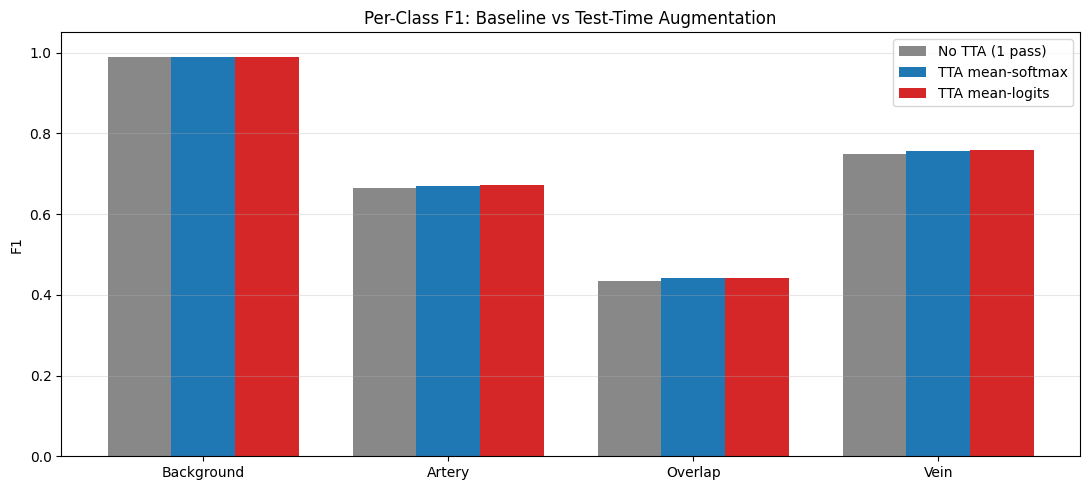

In [54]:
# =============================================================================
# Per-Class F1 -- Grouped Bar Chart
# =============================================================================

x = np.arange(len(CLASS_NAMES))
width = 0.26

plt.figure(figsize=(11, 5))

for offset, v, colour in [
    (-width, "baseline",  "#888888"),
    (0.0,    "tta_prob",  "#1f77b4"),
    (width,  "tta_logit", "#d62728"),
]:

    plt.bar(
        x + offset,
        tta_results[v]["f1"],
        width,
        label=VARIANT_LABELS[v],
        color=colour
    )

plt.xticks(x, CLASS_NAMES)
plt.ylabel("F1")
plt.title("Per-Class F1: Baseline vs Test-Time Augmentation")
plt.ylim(0, 1.05)
plt.grid(True, axis="y", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

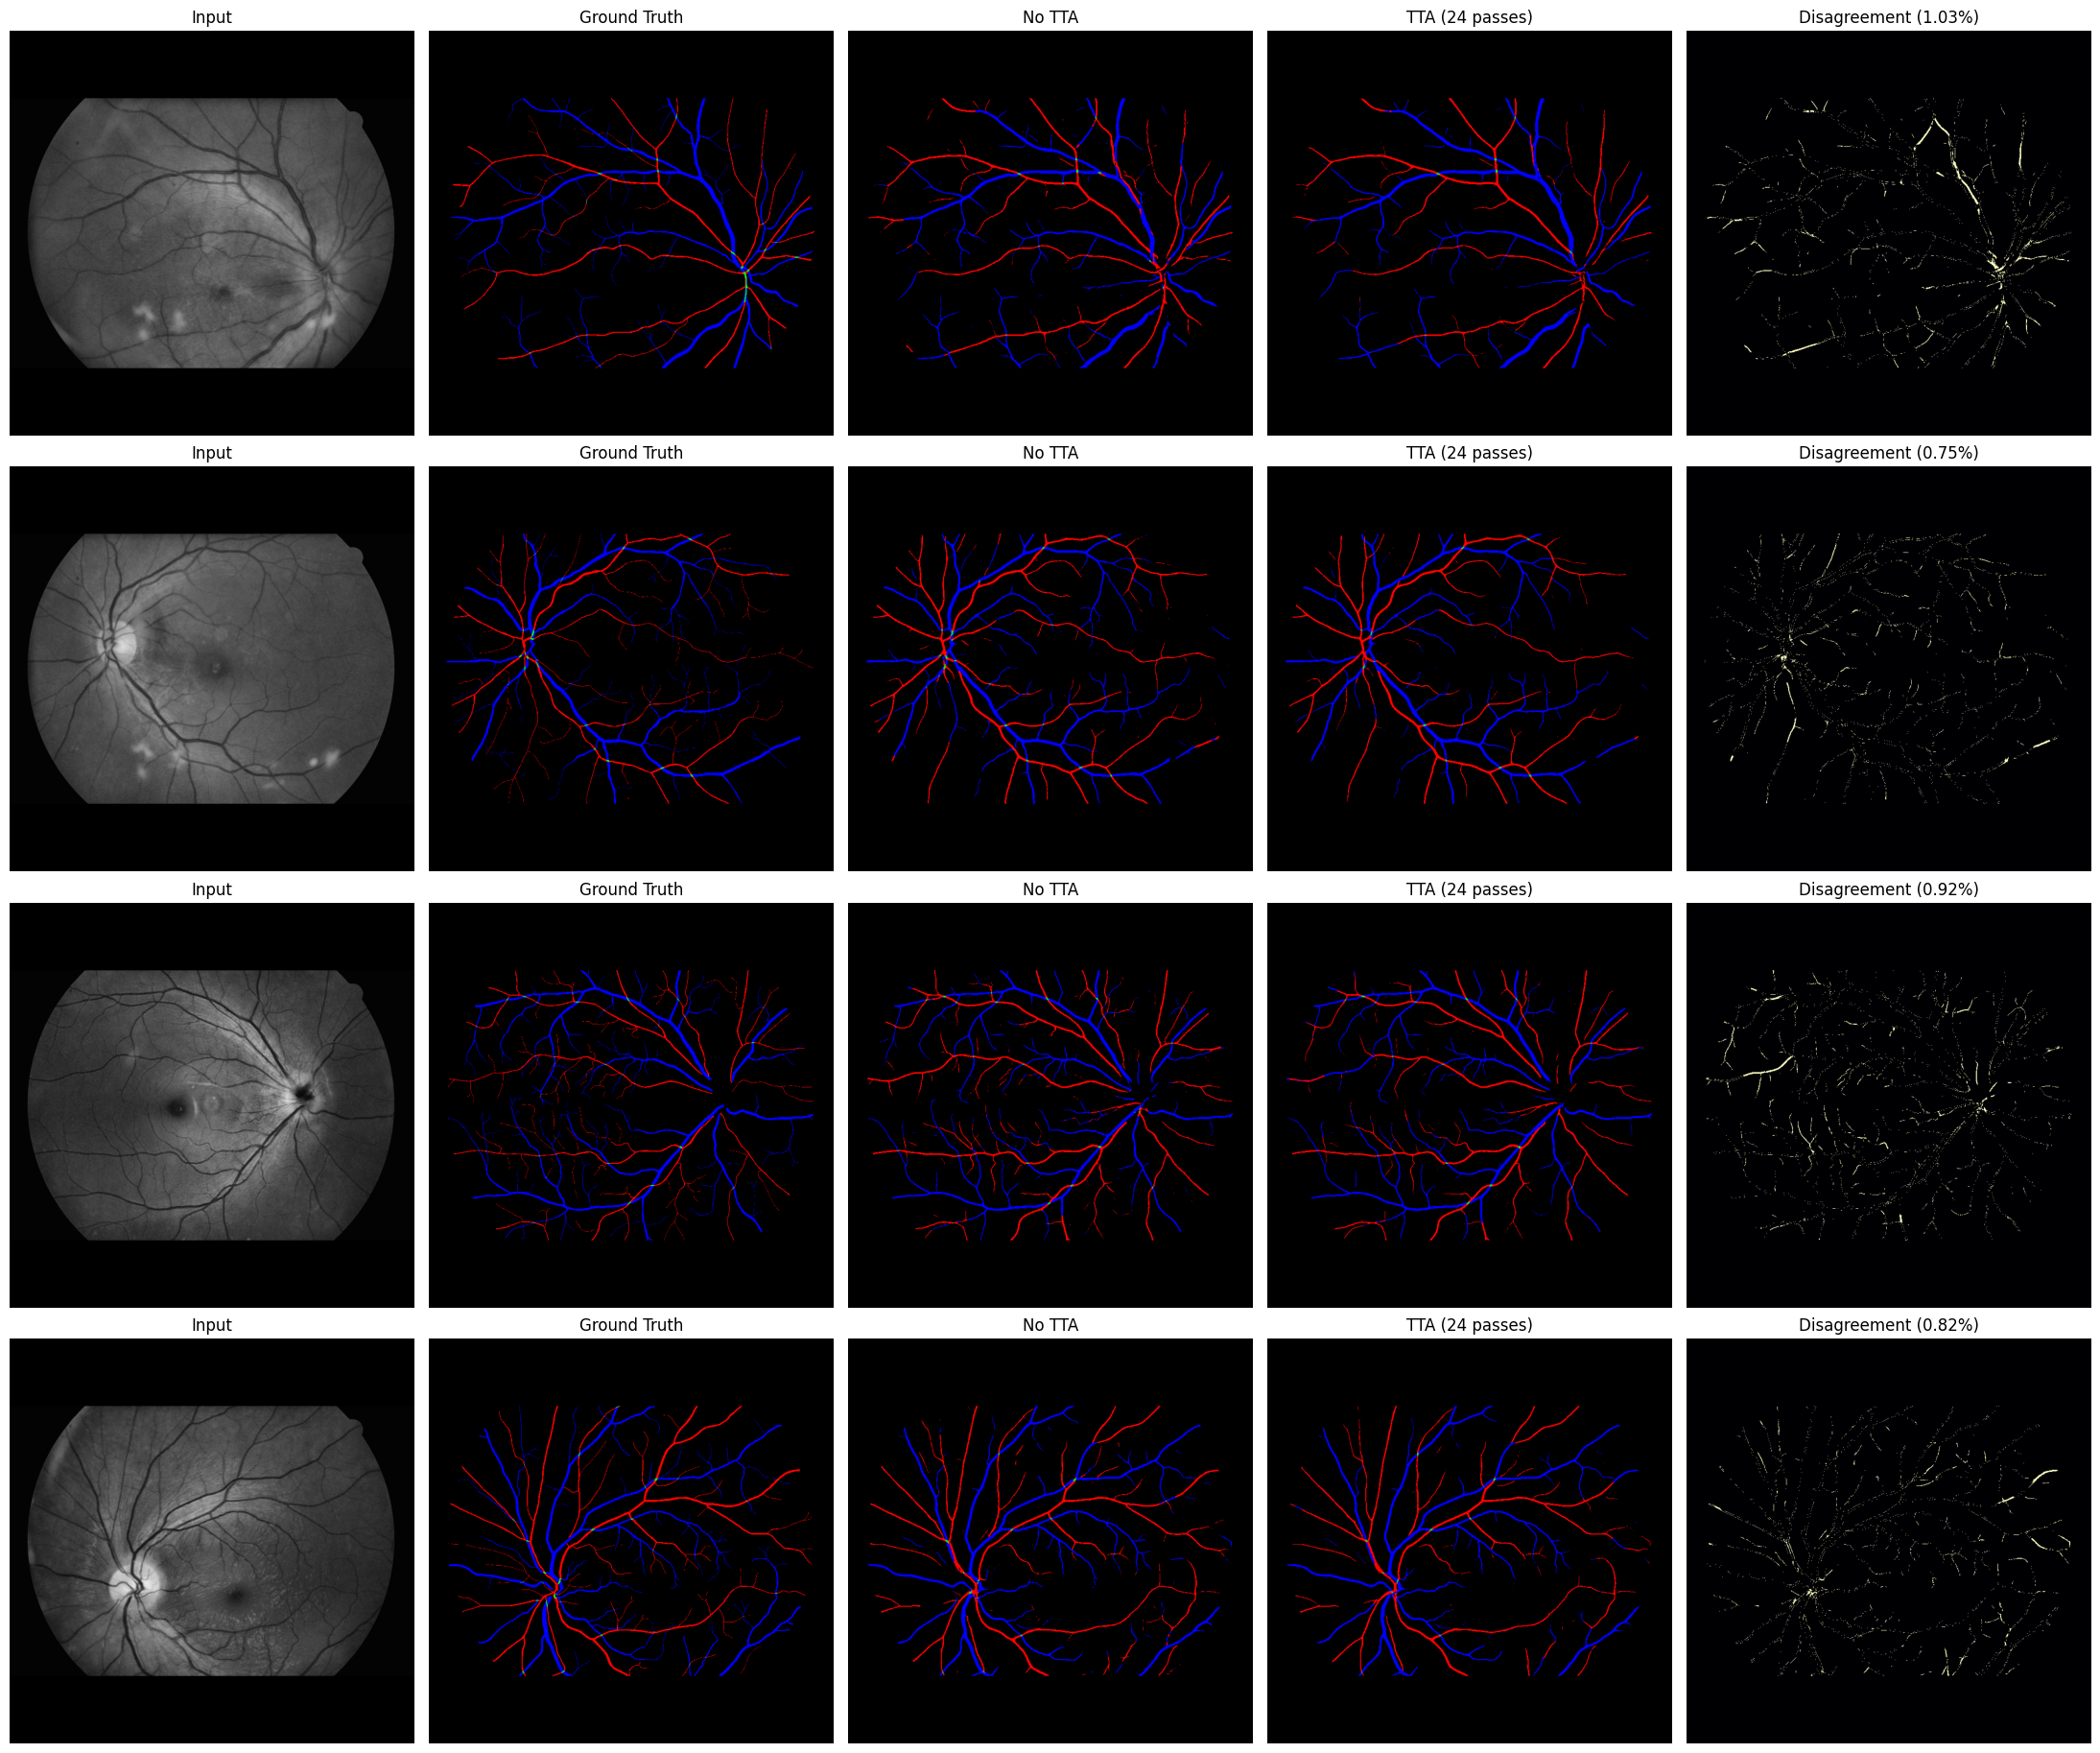

In [55]:
# =============================================================================
# Qualitative Comparison: Baseline vs TTA
# =============================================================================

model.eval()

num_examples = 4

indices = np.random.choice(
    len(test_dataset),
    min(num_examples, len(test_dataset)),
    replace=False
)

fig, axes = plt.subplots(
    len(indices),
    5,
    figsize=(22, 4.6 * len(indices))
)

if len(indices) == 1:
    axes = axes[None, :]

with torch.no_grad():

    for row, idx in enumerate(indices):

        image, gt = test_dataset[idx]

        image_gpu = image.unsqueeze(0).to(DEVICE, non_blocking=True)

        # Baseline
        with torch.amp.autocast("cuda"):
            baseline_logits = model(image_gpu)[0]

        baseline_pred = torch.argmax(
            baseline_logits.float(), dim=1
        ).squeeze(0).cpu().numpy()

        # TTA
        merged = predict_tta(model, image_gpu)

        tta_pred = torch.argmax(
            merged["prob"], dim=1
        ).squeeze(0).cpu().numpy()

        gt = gt.numpy()

        # Where TTA and baseline disagree
        disagreement = (baseline_pred != tta_pred)

        panels = [
            (image.permute(1, 2, 0).numpy(), "Input"),
            (class_to_rgb(gt), "Ground Truth"),
            (class_to_rgb(baseline_pred), "No TTA"),
            (class_to_rgb(tta_pred), f"TTA ({merged['passes']} passes)"),
            (disagreement, f"Disagreement ({disagreement.mean() * 100:.2f}%)"),
        ]

        for col, (img, title) in enumerate(panels):

            ax = axes[row, col]

            if col == 4:
                ax.imshow(img, cmap="magma")
            else:
                ax.imshow(img)

            ax.set_title(title)
            ax.axis("off")

plt.tight_layout()
plt.show()

del merged, baseline_logits
torch.cuda.empty_cache()